# PRCP-1016- Heart Disease Pred
## Capstone Project – Healthcare Domain

---

| Field | Details |
|-------|---------|
| **Project Code** | PRCP-1016-HeartDieseasePred |
| **Domain** | Healthcare |
| **Objective** | Predict whether a patient is likely to have heart disease using machine learning techniques. |
| **Dataset** | Heart Disease Dataset |

---


### Project Overview

Heart disease is one of the leading causes of death worldwide. Early prediction and diagnosis can help reduce health risks and improve patient outcomes. This project aims to analyze patient health data and build machine learning models that predict whether a patient is likely to have heart disease.

The project includes:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Machine Learning model building
- Model comparison
- Best model selection
- Hospital recommendations

## Table of Contents
1. [Setup & Imports](#1-setup)
2. [Data Loading & Overview](#2-data)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Data Preprocessing](#4-preprocessing)
5. [Model Building & Comparison](#5-models)
6. [Best Model & Evaluation](#6-best-model)
7. [Hospital Recommendations](#7-recommendations)
8. [Challenges & Techniques](#8-challenges)
9. [Conclusion ](#9-conclusion)




## Business Problem:
Develop a predictive healthcare system that identifies potential heart disease cases for early diagnosis and prevention.

## 1. Setup & Imports <a id='1-setup'></a>

In [2]:
# Data Handling
import pandas as pd
import numpy as np

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Data Splitting and Validation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

# Data Preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# Machine Learning Models
from sklearn.linear_model import LogisticRegression

# Tree Based Models
from sklearn.tree import DecisionTreeClassifier

# Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

# Support Vector Machine
from sklearn.svm import SVC

# Distance-Based Model
from sklearn.neighbors import KNeighborsClassifier

# Probabilistic Model 
from sklearn.naive_bayes import GaussianNB

#Boosting Model
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("All libraries imported successfully")


All libraries imported successfully


## 2. Data Loading & Overview <a id='2-data'></a>

In [3]:
values = pd.read_csv(r'C:\Users\HP Pavilion 15 Touch\Downloads\PRCP-1016-HeartDieseasePred\Data\values.csv');

labels = pd.read_csv(r'C:\Users\HP Pavilion 15 Touch\Downloads\PRCP-1016-HeartDieseasePred\Data\labels.csv');

print("Files are Sucessfully Uploded")


Files are Sucessfully Uploded


In [4]:
# Merge Dataset
df = pd.merge(
    values,
    labels,
    on='patient_id'
)
print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (180, 15)


# Observation:

The dataset contains 180 patient records and health-related attributes used to predict heart disease.

In [5]:
# ── Basic Info ───────────────────────────────────────────────────────────────
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11 

In [6]:
# Statistical Summary

print("\nSTATISTICAL SUMMARY (Numerical Features)")

display(
    df.describe().round(2)
)


STATISTICAL SUMMARY (Numerical Features)


,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00
mean,1.55,131.31,3.16,0.69,0.16,1.05,249.21,1.01,0.69,54.81,149.48,0.32,0.44
std,0.62,17.01,0.94,0.97,0.37,1.00,52.72,1.12,0.46,9.33,22.06,0.47,0.50
min,1.00,94.00,1.00,0.00,0.00,0.00,126.00,0.00,0.00,29.00,96.00,0.00,0.00
25%,1.00,120.00,3.00,0.00,0.00,0.00,213.75,0.00,0.00,48.00,132.00,0.00,0.00
50%,1.00,130.00,3.00,0.00,0.00,2.00,245.50,0.80,1.00,55.00,152.00,0.00,0.00
75%,2.00,140.00,4.00,1.00,0.00,2.00,281.25,1.60,1.00,62.00,166.25,1.00,1.00
max,3.00,180.00,4.00,3.00,1.00,2.00,564.00,6.20,1.00,77.00,202.00,1.00,1.00


In [7]:
df.describe(include='object')

,patient_id,thal
count,180,180
unique,180,3
top,0z64un,normal
freq,1,98


Observation:

The statistical summary provides an overview of numerical variables including central tendency and variability of the dataset.

It helps identify:
- Range of feature values
- Average values of variables
- Presence of potential outliers
- Overall data distribution

This analysis supports data preprocessing and feature understanding before model building.

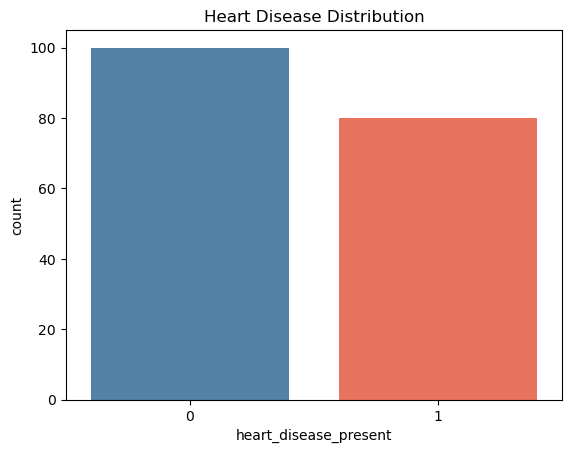

In [8]:
## Target Distribution

# Count of target classes

df['heart_disease_present'].value_counts()

# Visualization

sns.countplot(
x='heart_disease_present',
data=df,
palette=['steelblue','tomato']
)

plt.title(
'Heart Disease Distribution'
)

plt.show()



# Observation:

* Most patients belong to either disease or no disease category.
* The graph shows the distribution of target classes.
* This helps identify whether the dataset is balanced.
* Target analysis is important before training machine learning models.


In [9]:
# Missing Values Analysis

print("MISSING VALUE ANALYSIS")

missing = df.isnull().sum()

print(
missing
)

print(
"\nTotal Missing Values:",
missing.sum()
)


MISSING VALUE ANALYSIS
patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

Total Missing Values: 0


In [10]:
# Duplicate Check

dupes = df.duplicated().sum()

print(
"Duplicate Rows:",
dupes
)

print(
"Unique Patients:",
df['patient_id'].nunique()
)

print(
"Total Records:",
len(df)
)


Duplicate Rows: 0
Unique Patients: 180
Total Records: 180


# Observation:

- Duplicate value analysis was performed to identify repeated records.
- No duplicate rows were found in the dataset.
- Patient IDs appear to be unique identifiers.
- No duplicate removal was required before preprocessing.

## 3. Exploratory Data Analysis (EDA) <a id='3-eda'></a>

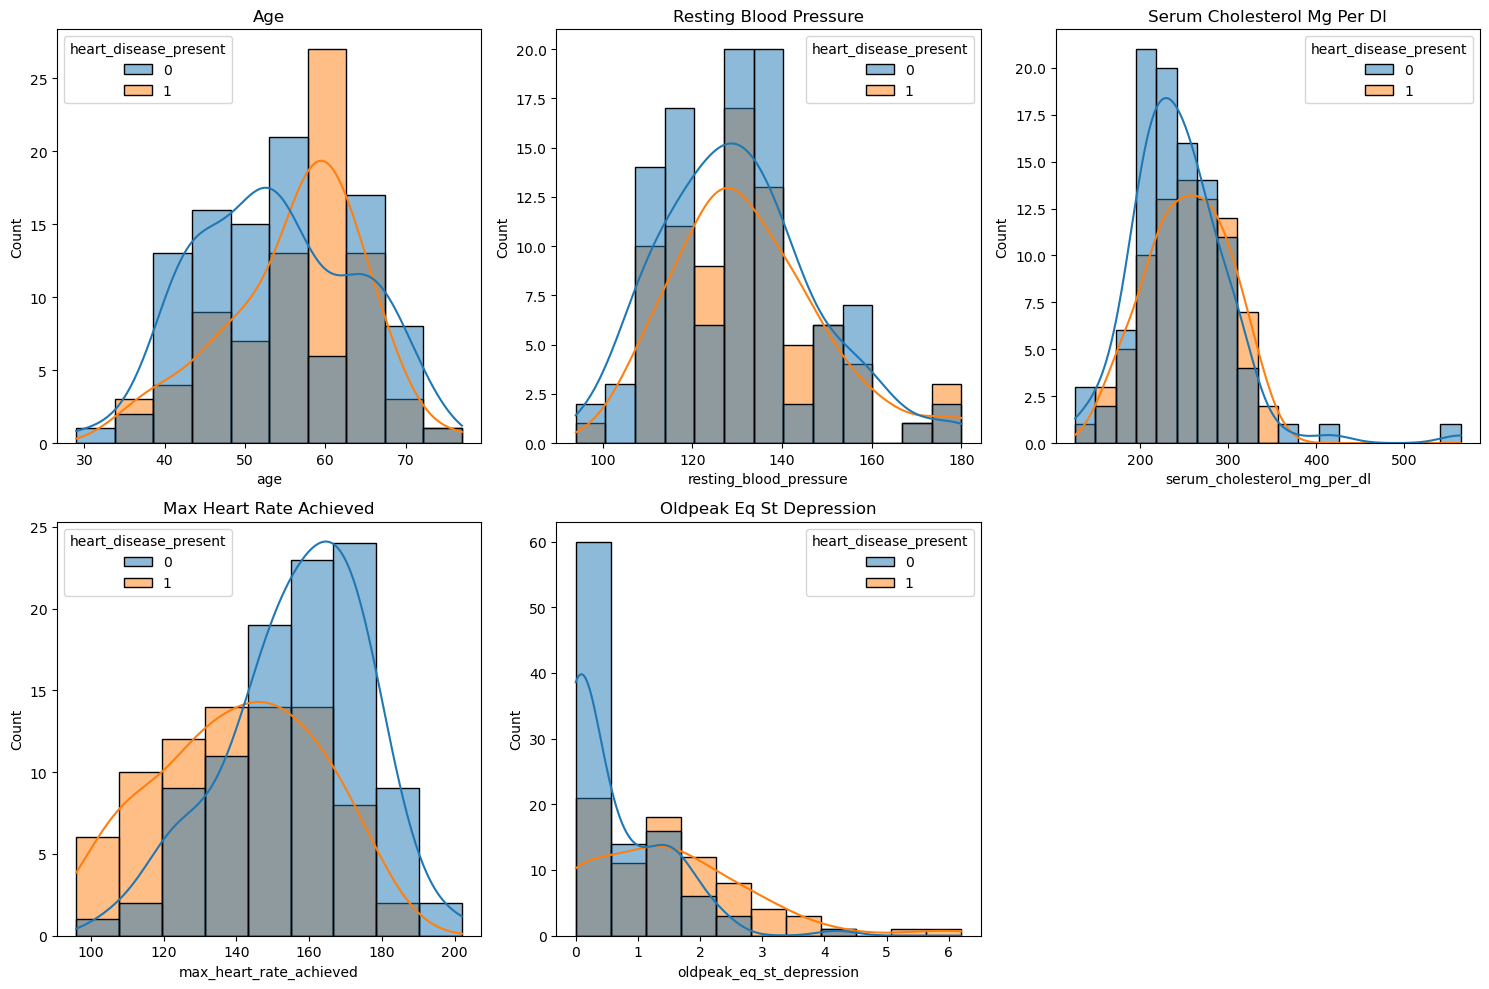

In [11]:
# Numerical Feature Distribution

num_cols = [
    'age',
    'resting_blood_pressure',
    'serum_cholesterol_mg_per_dl',
    'max_heart_rate_achieved',
    'oldpeak_eq_st_depression'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):

    plt.subplot(2,3,i+1)

    sns.histplot(
        data=df,
        x=col,
        hue='heart_disease_present',
        kde=True
    )

    plt.title(
        col.replace('_',' ').title()
    )

plt.tight_layout()

plt.show()



## Observation:

- Numerical features were analyzed using histograms.
- The graphs show how values are distributed across patients.
- Some variables show different distributions for disease and non-disease groups.
- This helps understand patterns before model training.

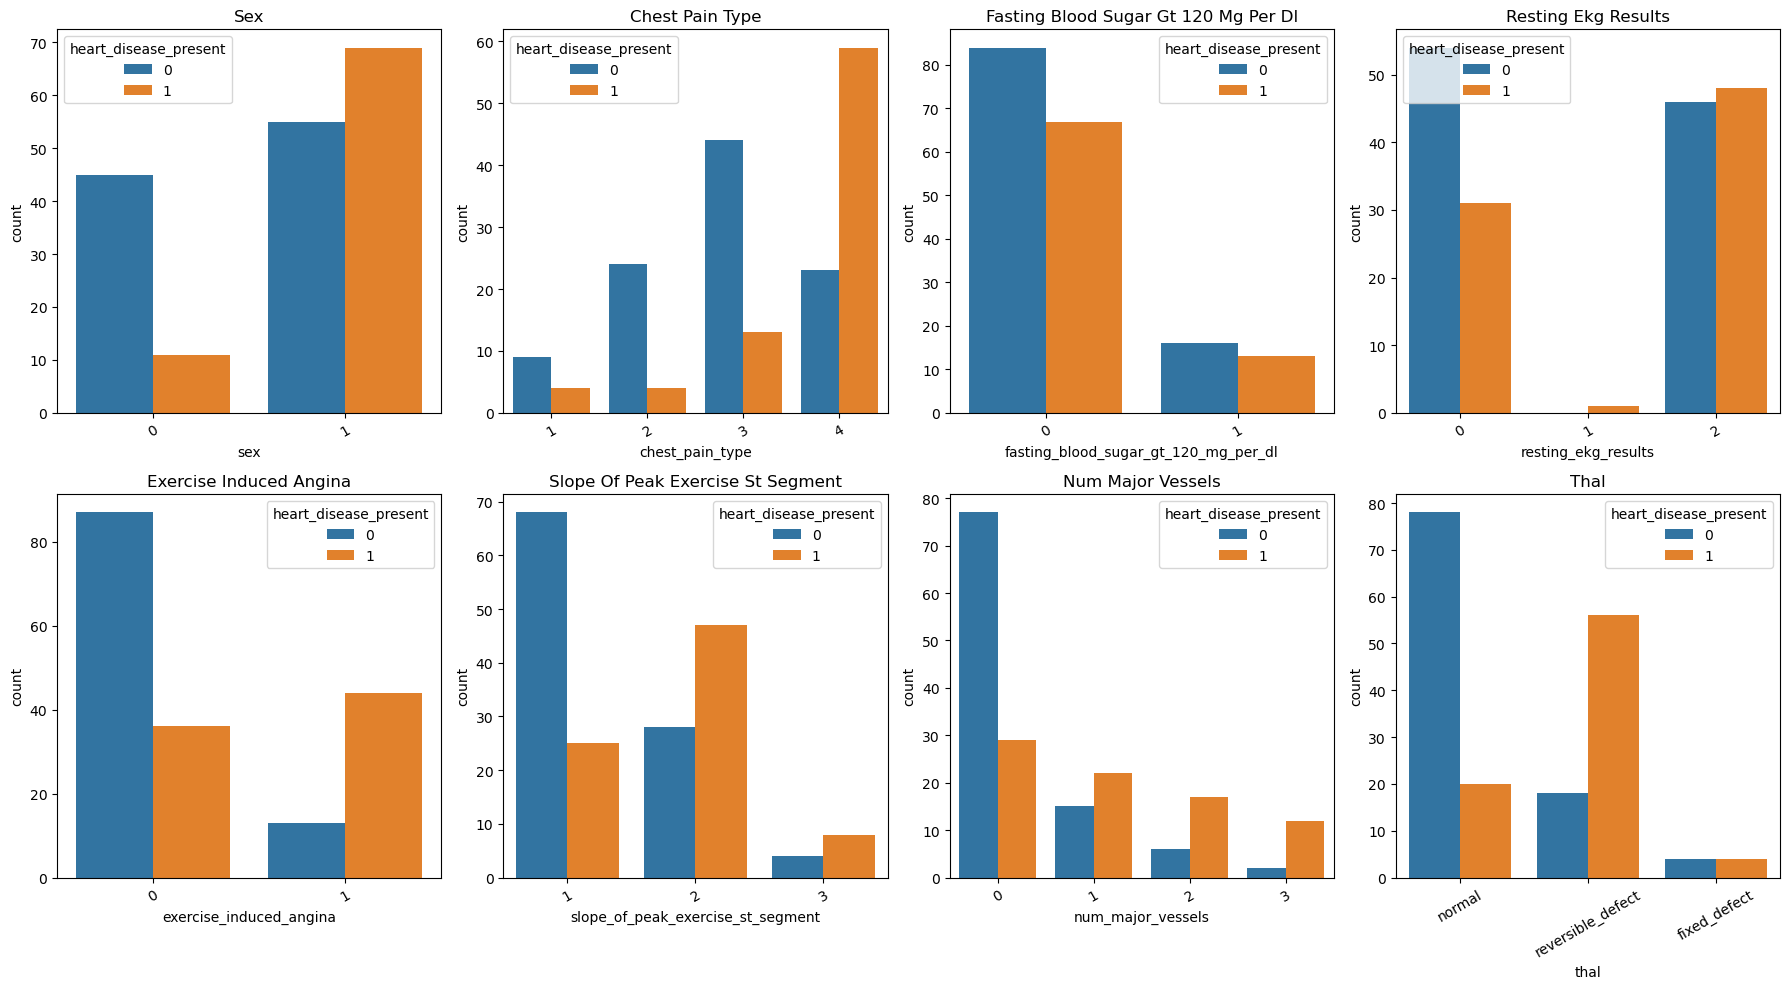

In [12]:
# Categorical Features vs Heart Disease

cat_cols = [
    'sex',
    'chest_pain_type',
    'fasting_blood_sugar_gt_120_mg_per_dl',
    'resting_ekg_results',
    'exercise_induced_angina',
    'slope_of_peak_exercise_st_segment',
    'num_major_vessels',
    'thal'
]

plt.figure(figsize=(18,10))

for i, col in enumerate(cat_cols):

    plt.subplot(2,4,i+1)

    sns.countplot(
        data=df,
        x=col,
        hue='heart_disease_present'
    )

    plt.xticks(rotation=30)

    plt.title(
        col.replace('_',' ').title()
    )

plt.tight_layout()

plt.show()


# Observation:

- Categorical features were analyzed with respect to heart disease.
- Count plots show how disease cases vary across categories.
- Some categories appear more associated with heart disease.
- This analysis helps understand relationships before model building.

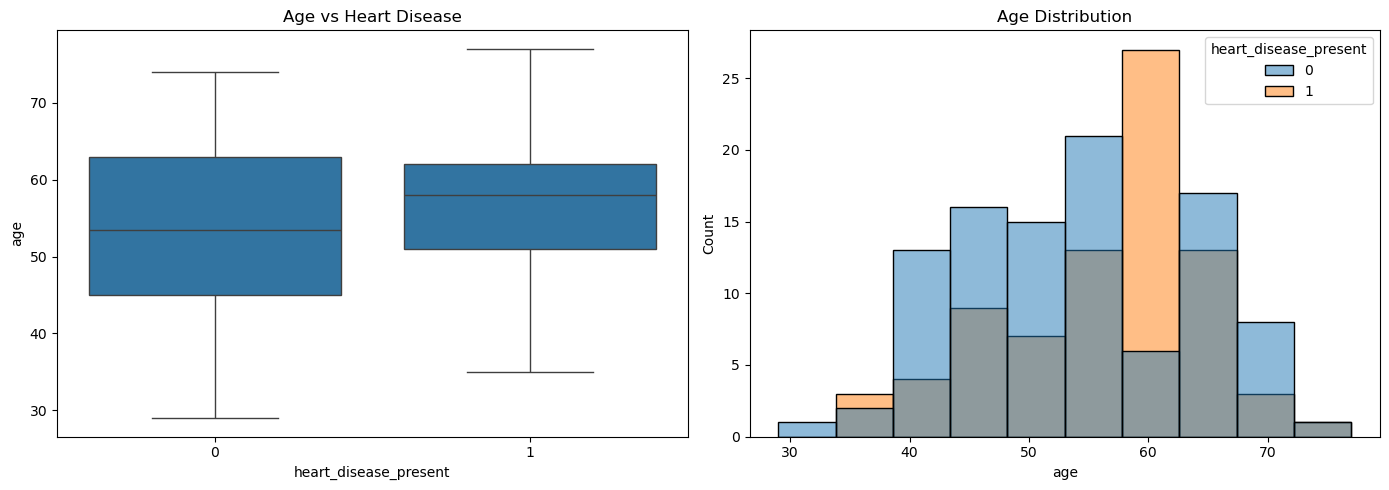

In [13]:
# Age Analysis

plt.figure(figsize=(14,5))

# Box Plot
plt.subplot(1,2,1)

sns.boxplot(
    data=df,
    x='heart_disease_present',
    y='age'
)

plt.title('Age vs Heart Disease')


# Histogram
plt.subplot(1,2,2)

sns.histplot(
    data=df,
    x='age',
    hue='heart_disease_present',
    bins=10
)

plt.title('Age Distribution')

plt.tight_layout()

plt.show()



# Observation:

- Age distribution was analyzed to understand its relationship with heart disease.
- The box plot compares patient age across disease groups.
- The histogram shows how age values are distributed.
- Age may influence heart disease prediction.

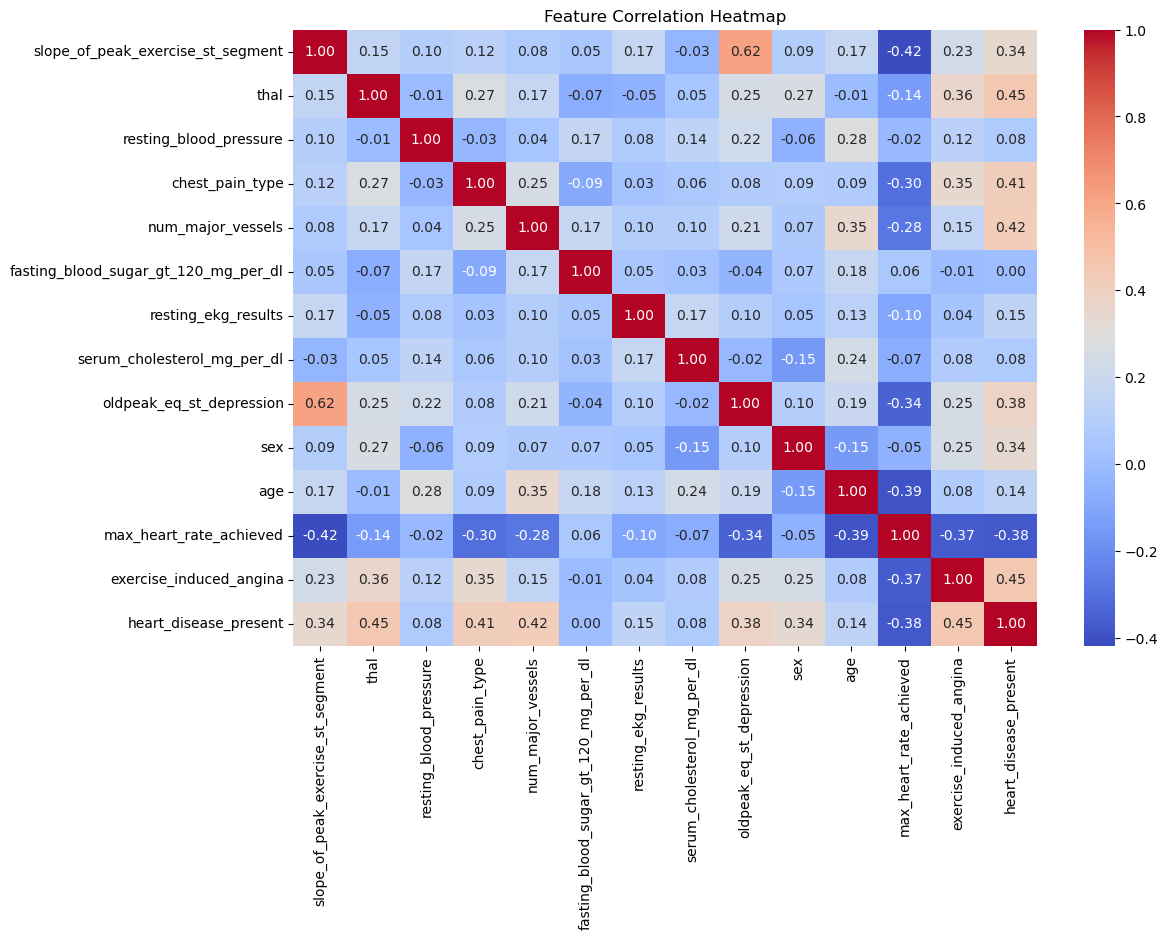

In [14]:
# Correlation Heatmap

df_heat = df.copy()

df_heat['thal'] = LabelEncoder().fit_transform(
    df_heat['thal']
)

df_heat.drop(
    ['patient_id'],
    axis=1,
    inplace=True,
    errors='ignore'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    df_heat.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Feature Correlation Heatmap'
)

plt.show()


# Observation:

- Heatmap was used to analyze relationships between numerical features.
- Correlation values closer to +1 indicate strong positive relationships.
- Correlation values closer to -1 indicate negative relationships.
- Values near 0 indicate weak relationships.
- Features with higher correlation to the target may be important for prediction.

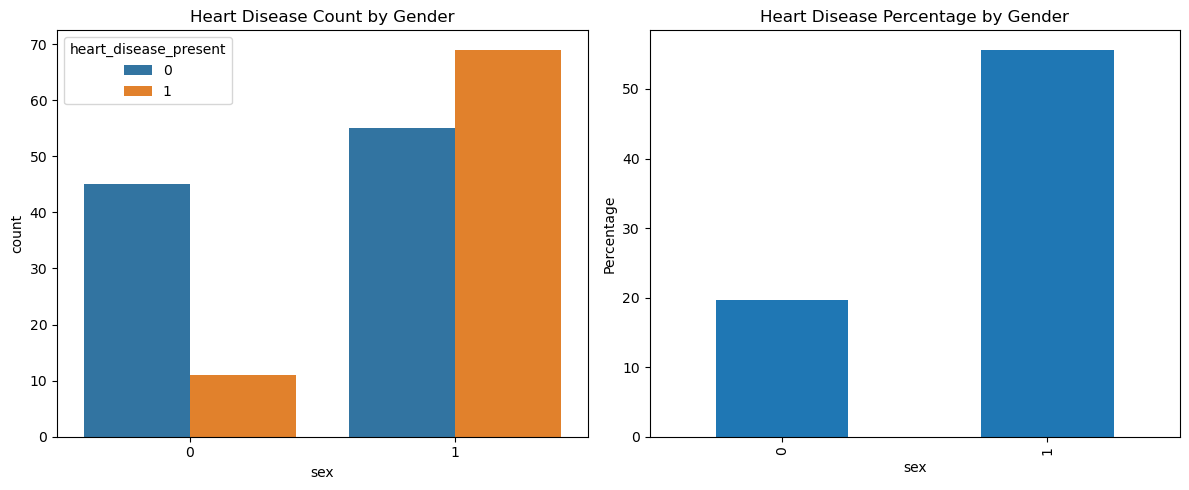

In [15]:
## Gender Analysis

plt.figure(figsize=(12,5))

# Count Plot

plt.subplot(1,2,1)

sns.countplot(
data=df,
x='sex',
hue='heart_disease_present'
)

plt.title(
'Heart Disease Count by Gender'
)

# Percentage Style Visualization

plt.subplot(1,2,2)

gender_rate = (
df.groupby('sex')
['heart_disease_present']
.mean()
*100
)

gender_rate.plot(
kind='bar'
)

plt.title(
'Heart Disease Percentage by Gender'
)

plt.ylabel(
'Percentage'
)

plt.tight_layout()

plt.show()



# Observation:

* Gender analysis was performed to understand differences in heart disease occurrence.
* The count plot shows the number of disease and non-disease cases by gender.
* The percentage chart helps compare disease rate across genders.
* Gender may influence heart disease prediction.


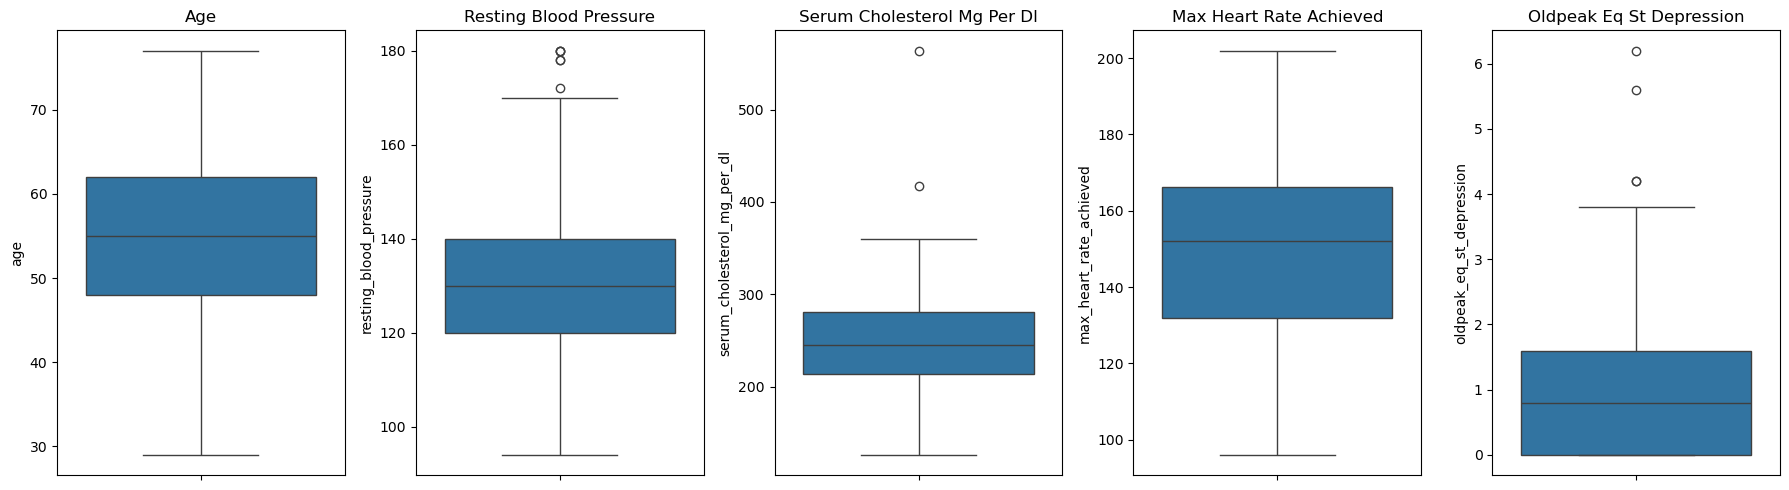

In [16]:
# Outlier Analysis

num_cols = [
    'age',
    'resting_blood_pressure',
    'serum_cholesterol_mg_per_dl',
    'max_heart_rate_achieved',
    'oldpeak_eq_st_depression'
]

plt.figure(figsize=(18,5))

for i, col in enumerate(num_cols):

    plt.subplot(1,5,i+1)

    sns.boxplot(
        y=df[col]
    )

    plt.title(
        col.replace(
            '_',
            ' '
        ).title()
    )

plt.tight_layout()

plt.show()



# Observation:

- Box plots were used to identify outliers in numerical variables.
- Values outside whiskers may indicate potential outliers.
- Some variables contain extreme values.
- Outlier analysis helps determine preprocessing requirements before model training.

## 4. Data Preprocessing <a id='4-preprocessing'></a>

In [17]:
## Data Preprocessing – Drop ID & Encode Categoricals

df_model = df.copy()

# Remove unnecessary columns

df_model.drop(
[
'patient_id',
'age_group'
],
axis=1,
inplace=True,
errors='ignore'
)

# Encode categorical column

le = LabelEncoder()

df_model['thal'] = le.fit_transform(
df_model['thal']
)

print(
"Dataset Shape:",
df_model.shape
)

df_model.head()



Dataset Shape: (180, 14)


,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,1,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,1,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,1,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,2,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,2,178,1,0,0,2,270,4.2,1,59,145,0,0


# Observation:

* Identifier columns were removed because they do not contribute to prediction.
* Categorical values were converted into numerical format using Label Encoding.
* The transformed dataset is now ready for machine learning algorithms.
* Data preprocessing improves model compatibility and performance.


In [18]:
## Feature and Target Split

X = df_model.drop(
'heart_disease_present',
axis=1
)

y = df_model[
'heart_disease_present'
]

print(
"Features Shape:",
X.shape
)

print(
"Target Shape:",
y.shape
)

print(
"\nFeatures Used:"
)

print(
list(X.columns)
)



Features Shape: (180, 13)
Target Shape: (180,)

Features Used:
['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina']


# Observation:

* The dataset was divided into independent features (X) and target variable (y).
* Features contain patient health attributes used for prediction.
* The target variable represents whether heart disease is present or not.
* This step prepares data for train-test splitting and model training.


In [19]:
## Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(


X,
y,

test_size=0.20,

random_state=42,

stratify=y

)

print(
"Training Shape:",
X_train.shape
)

print(
"Testing Shape:",
X_test.shape
)

print(
"\nTraining Disease Rate:",
round(
y_train.mean()*100,
2
),
"%"
)

print(
"Testing Disease Rate:",
round(
y_test.mean()*100,
2
),
"%"
)



Training Shape: (144, 13)
Testing Shape: (36, 13)

Training Disease Rate: 44.44 %
Testing Disease Rate: 44.44 %


# Observation:

* The dataset was divided into training and testing sets.
* 80% of the data was used for training and 20% for testing.
* Stratified splitting was applied to maintain class distribution.
* Random state was fixed to ensure reproducible results.
* This step helps evaluate model performance on unseen data.


In [26]:
# Feature Scaling

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)

X_test_sc = scaler.transform(X_test)


print("Feature Scaling Applied Successfully")

print("Scaled Training Shape:",X_train_sc.shape)

print("Scaled Testing Shape:",X_test_sc.shape)

print("Mean:",round(X_train_sc.mean(),2))

print("Standard Deviation:",round(X_train_sc.std(),2))

Feature Scaling Applied Successfully
Scaled Training Shape: (144, 13)
Scaled Testing Shape: (36, 13)
Mean: -0.0
Standard Deviation: 1.0



# Observation:

Observation:

- Feature scaling was applied using StandardScaler.
- Scaling transforms variables to a common scale.
- Training data was fitted first and testing data was transformed separately to avoid data leakage.
- After scaling, features have approximately mean = 0 and standard deviation = 1.
- Feature scaling improves the performance of distance-based and optimization-based algorithms.

## 5. Model Building & Comparison <a id='5-models'></a>

In [28]:
# Define Models

models = {

'Logistic Regression':LogisticRegression(max_iter=1000,random_state=42),

'Decision Tree':DecisionTreeClassifier(random_state=42),

'Random Forest':RandomForestClassifier(n_estimators=200,random_state=42),

'Gradient Boosting':GradientBoostingClassifier(n_estimators=200,random_state=42),

'AdaBoost':AdaBoostClassifier(n_estimators=100,random_state=42),

'XGBoost':XGBClassifier(n_estimators=200,eval_metric='logloss',random_state=42),

'SVM':SVC(probability=True,random_state=42),

'K-Nearest Neighbors':KNeighborsClassifier(n_neighbors=7),

'Naive Bayes':GaussianNB()
}

print(f"✅ {len(models)} models defined.")


✅ 9 models defined.


In [49]:
# ── 5.2 Train & Evaluate Models ─────────────────────────

results = []
for name, model in models.items():

    # Select scaled / original data
    if name in [ 'Logistic Regression', 'SVM', 'K-Nearest Neighbors' ]:
        Xtr, Xte = X_train_sc, X_test_sc

    else:
        Xtr, Xte = X_train, X_test


    # Train
    model.fit(Xtr, y_train)

    # Predict
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:,1]


    # Store Results
    results.append({

        'Model': name,

        'Accuracy':accuracy_score(y_test, y_pred),

        'Precision': precision_score(y_test, y_pred),

        'Recall':recall_score(y_test, y_pred),

        'F1 Score':f1_score(y_test, y_pred),

        'ROC-AUC':roc_auc_score(y_test, y_proba)

    })


# Create Table
results_df = pd.DataFrame(results)

# Sort
results_df = results_df.sort_values(
    'F1 Score',
    ascending=False
)

print("\n✅ All models trained and evaluated \n",results_df)



✅ All models trained and evaluated 
                  Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
2        Random Forest  0.916667   0.842105  1.0000  0.914286  0.959375
8          Naive Bayes  0.888889   0.833333  0.9375  0.882353  0.928125
3    Gradient Boosting  0.888889   0.833333  0.9375  0.882353  0.928125
4             AdaBoost  0.861111   0.761905  1.0000  0.864865  0.940625
7  K-Nearest Neighbors  0.861111   0.789474  0.9375  0.857143  0.948438
0  Logistic Regression  0.833333   0.777778  0.8750  0.823529  0.937500
5              XGBoost  0.805556   0.714286  0.9375  0.810811  0.937500
6                  SVM  0.805556   0.736842  0.8750  0.800000  0.946875
1        Decision Tree  0.750000   0.684211  0.8125  0.742857  0.756250


Random Forest             0.7989 0.8017 0.8818 0.8398 0.8665   0.8562


Gradient Boosting         0.7663 0.8131 0.7909 0.8018 0.8609   0.8419


AdaBoost                  0.8098 0.8319 0.8545 0.8430 0.9029   0.8445


XGBoost                   0.7717 0.8091 0.8091 0.8091 0.8652   0.8389


SVM                       0.8098 0.8319 0.8545 0.8430 0.8725   0.8280
K-Nearest Neighbors       0.7391 0.7719 0.8000 0.7857 0.7792   0.7890
Naive Bayes               0.7880 0.8142 0.8364 0.8251 0.8686   0.8302

✅ All models trained and evaluated.


# Observation:

- Multiple models were trained and evaluated.
- Accuracy, Precision, Recall, F1 Score and ROC-AUC were used.
- Comparison helps identify the best performing model.
- Final model selection was based on overall performance.

  To compare multiple machine learning algorithms and select the most suitable model for heart disease prediction.

In [50]:
results_df.columns

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'], dtype='object')

In [53]:
# ── 5.3 Model Comparison Table ─────────────────────────

print("\nMODEL COMPARISON REPORT")
print("="*70)

display(results_df.set_index('Model').style.format('{:.4f}')
.background_gradient(
cmap='YlGnBu',
subset=['Accuracy','F1 Score','ROC-AUC'])

.highlight_max(color='lightgreen')

.set_caption('Heart Disease Model Performance')
)



MODEL COMPARISON REPORT


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Random Forest,0.9167,0.8421,1.0000,0.9143,0.9594
Naive Bayes,0.8889,0.8333,0.9375,0.8824,0.9281
Gradient Boosting,0.8889,0.8333,0.9375,0.8824,0.9281
AdaBoost,0.8611,0.7619,1.0000,0.8649,0.9406
K-Nearest Neighbors,0.8611,0.7895,0.9375,0.8571,0.9484
Logistic Regression,0.8333,0.7778,0.8750,0.8235,0.9375
XGBoost,0.8056,0.7143,0.9375,0.8108,0.9375
SVM,0.8056,0.7368,0.8750,0.8000,0.9469
Decision Tree,0.7500,0.6842,0.8125,0.7429,0.7562


# Observation:

- Model performance metrics were compared systematically.
- Random Forest achieved the highest Accuracy and F1 Score.
- ROC-AUC indicates strong classification performance.
- The comparison table supports final model selection.

  This table helps compare model performance and select the best algorithm based on multiple evaluation metrics.

<Figure size 1200x600 with 0 Axes>

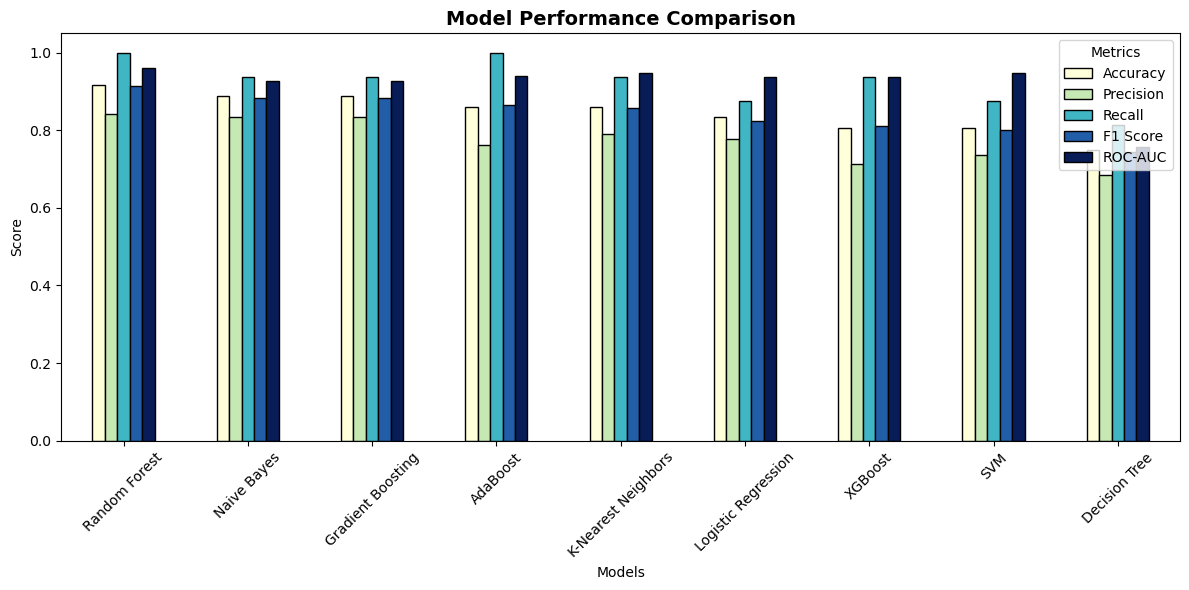

In [54]:
# ── 5.4 Comparison Bar Chart ─────────────────────────────────────

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics]

plt.figure(figsize=(12, 6))

plot_df.plot(
    kind='bar',
    figsize=(12, 6),
    colormap='YlGnBu',
    edgecolor='black'
)

plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title='Metrics')
plt.tight_layout()

plt.show()


# Observation:

- Performance of all machine learning models was compared visually.
- Multiple evaluation metrics were analyzed together.
- Random Forest achieved the strongest overall performance.
- Visualization helped identify the best prediction model.

  Bar charts provide an easy way to compare model performance across multiple evaluation metrics and support model selection.

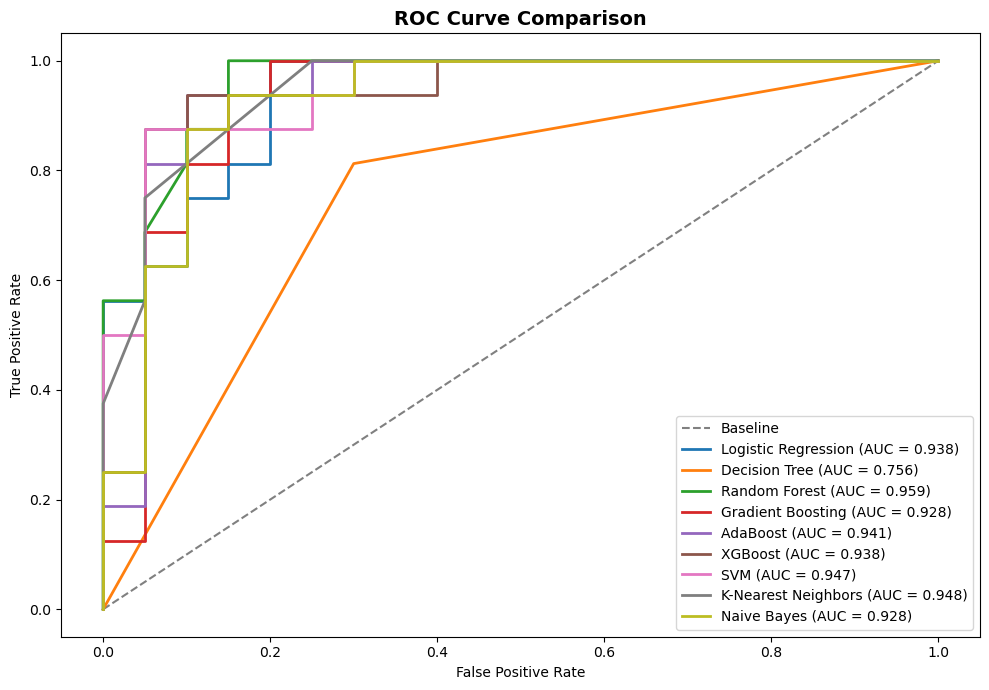

In [55]:
# ── 5.5 ROC Curve Comparison ───────────────────────────

plt.figure(figsize=(10, 7))

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline')

for name, model in models.items():

    Xte = X_test_sc if name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors'] else X_test

    y_proba = model.predict_proba(Xte)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_score:.3f})')

plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


# Observation:

- ROC curves were generated to compare classification performance.
- Higher ROC-AUC values indicate better prediction capability.
- Random Forest achieved the strongest overall ROC performance.
- ROC analysis supported final model selection.

    ROC Curve measures how well models distinguish between disease and non-disease classes across different thresholds.

## 6. Best Model – Deep Dive <a id='6-best-model'></a>

In [56]:
# ── 6.1 Identify Best Model ─────────────────────────

best_name = results_df.iloc[0]['Model']
best_model = models[best_name]

print("BEST MODEL SELECTED")
print("="*40)

print(f"Model      : {best_name}")
print(f"Accuracy   : {results_df.iloc[0]['Accuracy']:.4f}")
print(f"F1 Score   : {results_df.iloc[0]['F1 Score']:.4f}")
print(f"ROC-AUC    : {results_df.iloc[0]['ROC-AUC']:.4f}")

BEST MODEL SELECTED
Model      : Random Forest
Accuracy   : 0.9167
F1 Score   : 0.9143
ROC-AUC    : 0.9594


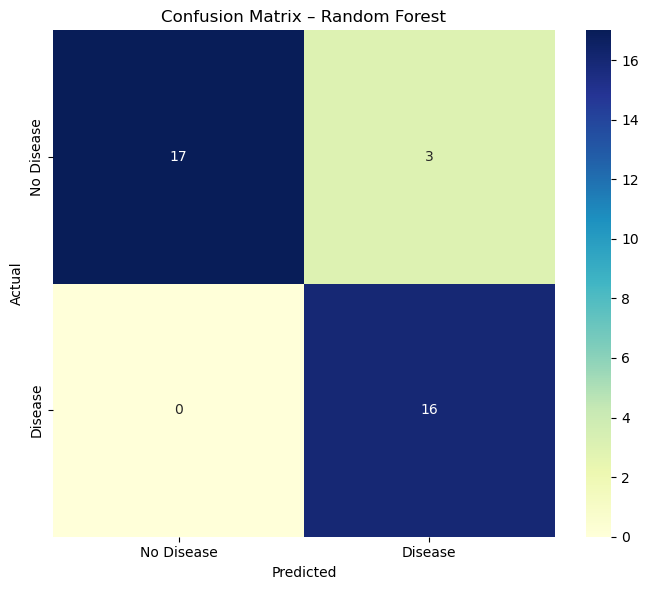

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.84      1.00      0.91        16

    accuracy                           0.92        36
   macro avg       0.92      0.93      0.92        36
weighted avg       0.93      0.92      0.92        36



In [57]:
# ── 6.2 Confusion Matrix ─────────────────────────────

Xte_best = X_test_sc if best_name in [
    'Logistic Regression',
    'SVM',
    'K-Nearest Neighbors'
] else X_test


y_pred_best = best_model.predict(Xte_best)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.title(
    f'Confusion Matrix – {best_name}'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.tight_layout()

plt.show()


print(
    classification_report(
        y_test,
        y_pred_best
    )
)


# Observation:

- Confusion Matrix was used to evaluate prediction results.
- Most samples were classified correctly.
- The model showed strong disease detection capability.
- Classification Report provided Precision, Recall and F1 Score.

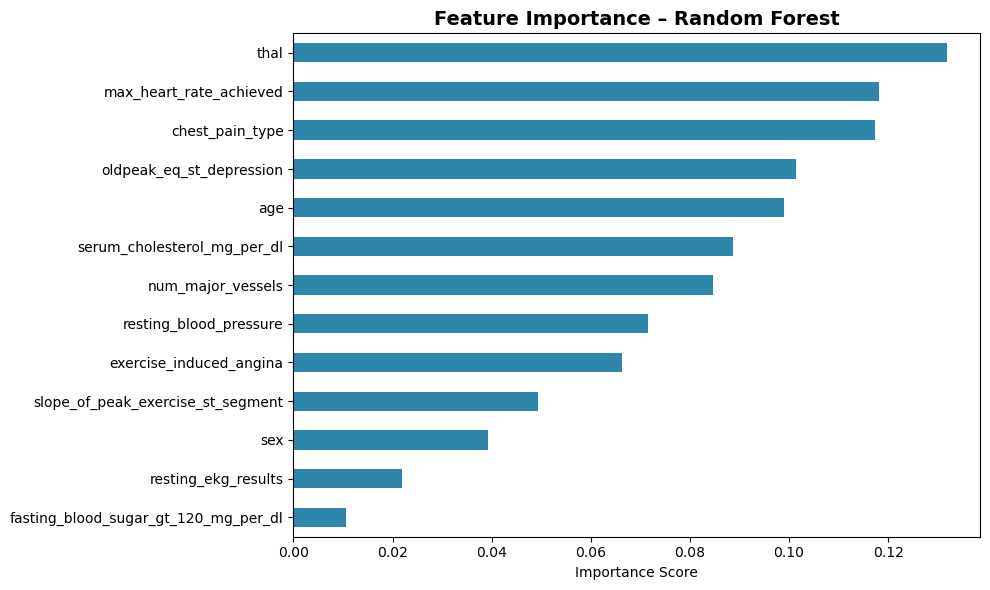


Top 5 Important Features
thal                        0.131923
max_heart_rate_achieved     0.118120
chest_pain_type             0.117361
oldpeak_eq_st_depression    0.101459
age                         0.098884
dtype: float64


In [59]:
# ── 6.3 Feature Importance ─────────────────────────

if hasattr(best_model, 'feature_importances_'):

    feature_imp = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values()

    plt.figure(figsize=(10,6))

    feature_imp.plot(
        kind='barh',
        color='#2E86AB'
    )

    plt.title(
        f'Feature Importance – {best_name}',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel(
        'Importance Score'
    )

    plt.tight_layout()

    plt.show()


    print("\nTop 5 Important Features")

    print(
        feature_imp
        .sort_values(
            ascending=False
        )
        .head(5)
    )


# Observation:

- Feature importance analysis was performed to identify influential variables.
- The model ranked features based on contribution to prediction.
- Important health indicators had greater impact on heart disease prediction.
- Feature importance improved model interpretability.

  Feature importance helps identify which patient health factors contribute most to prediction results.

Cross Validation Results – Random Forest
Fold 1: 0.8696
Fold 2: 0.7407
Fold 3: 0.7857
Fold 4: 0.7500
Fold 5: 0.8182

Mean F1 Score : 0.7928
Standard Dev. : 0.0472


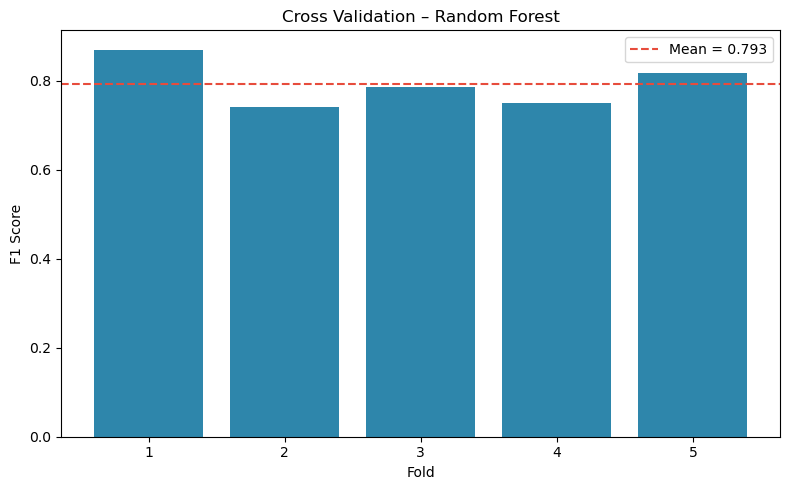

In [60]:
# ── 6.4 Cross-Validation Summary ─────────────────────

Xtr_best = X_train_sc if best_name in [
    'Logistic Regression',
    'SVM',
    'K-Nearest Neighbors'
] else X_train


cv_scores = cross_val_score(
    best_model,
    Xtr_best,
    y_train,
    cv=5,
    scoring='f1'
)


print(f'Cross Validation Results – {best_name}')

for i, score in enumerate(cv_scores, 1):
    print(f'Fold {i}: {score:.4f}')

print(f'\nMean F1 Score : {cv_scores.mean():.4f}')
print(f'Standard Dev. : {cv_scores.std():.4f}')


plt.figure(figsize=(8,5))

plt.bar(
    range(1,6),
    cv_scores,
    color='#2E86AB'
)

plt.axhline(
    cv_scores.mean(),
    color='#E74C3C',
    linestyle='--',
    label=f'Mean = {cv_scores.mean():.3f}'
)

plt.title(
    f'Cross Validation – {best_name}'
)

plt.xlabel(
    'Fold'
)

plt.ylabel(
    'F1 Score'
)

plt.xticks(
    range(1,6)
)

plt.legend()

plt.tight_layout()

plt.show()


# Observation:

-Cross-validation was performed to measure model stability.
- Performance remained consistent across multiple folds.
- Low standard deviation indicates reliable prediction capability.
- Random Forest showed strong generalization performance.

   Cross-validation evaluates model reliability by testing performance on multiple training splits.


# 7. Hospital Recommendations & Clinical Insights

## 🏥 Strategic Recommendations for Healthcare Providers

Based on exploratory analysis and machine learning model findings, the following recommendations are proposed to support early identification and monitoring of potential heart disease cases.

---

### 7.1 High-Risk Patient Identification

The prediction model can be used as an initial screening support tool to identify patients who may require additional clinical attention.

Potential indicators observed in the analysis:

- Higher age groups showed increased heart disease occurrence
- Elevated ST depression (oldpeak) may indicate increased risk
- Certain chest pain categories showed stronger association with disease
- Exercise-induced angina may contribute to prediction outcomes
- Number of major vessels and thallium test results influenced model decisions

---

### 7.2 Operational Recommendations

| Recommendation | Action | Priority |
|----------------|--------|----------|
| Screening Support | Use model output as an additional screening indicator | 🔴 High |
| Clinical Review | Forward higher-risk predictions for physician evaluation | 🔴 High |
| Preventive Monitoring | Encourage periodic cardiovascular screening | 🟡 Medium |
| Patient Education | Promote awareness of healthy lifestyle practices | 🟡 Medium |
| Data Monitoring | Track prediction performance over time | 🟢 Low |

---

### 7.3 Public Health Awareness

Suggested awareness activities:

- Promote regular exercise and healthy dietary habits
- Encourage routine blood pressure and health checkups
- Increase awareness about cardiovascular risk factors
- Encourage early consultation when symptoms appear

---

### 7.4 Model Deployment Considerations

Before practical deployment:

- Validate model performance on real hospital datasets
- Periodically retrain using updated data
- Monitor evaluation metrics such as Accuracy, Recall and ROC-AUC
- Use the model as a decision-support system only
- Final diagnosis should remain with healthcare professionals
- Follow patient privacy and data protection standards

---

## Observation

- Machine learning can support early heart disease risk assessment.
- Model predictions may assist healthcare workflows.
- Continuous validation is required before deployment.
- Human clinical decision-making remains essential.

## 8. Challenges Faced & Techniques Used <a id='8-challenges'></a>

### 📋 Data & Modelling Challenges Report

| # | Challenge | Technique Used | Reason |
|---|---|---|---|
| 1 | **Class Imbalance** (60/40 split) | Stratified train-test split; F1/AUC as metrics (not just accuracy) | Accuracy alone misleads when classes are skewed; stratification preserves distribution |
| 2 | **Categorical feature – `thal`** | LabelEncoder (ordinal) | Thal has 3 ordered severity levels; LabelEncoding preserves relative meaning |
| 3 | **Feature Scaling needed for distance-based models** | StandardScaler applied selectively (LR, SVM, KNN) | Tree-based models are scale-invariant; scaling only where necessary prevents data leakage |
| 4 | **Outliers in blood pressure, cholesterol** | IQR detection; kept in dataset | Medical outliers are often clinically meaningful (hypertensive crisis, hypercholesterolemia) — removing them could harm recall |
| 5 | **Model selection among 9 models** | Cross-validation (5-fold StratifiedKFold) + multi-metric comparison | CV prevents overfitting illusion; recall is critical in healthcare (missing a disease is costlier than a false alarm) |
| 6 | **Overfitting risk in tree models** | `n_estimators=200`, default `max_depth` for Random Forest/GBM | Ensembles reduce variance; no aggressive depth pruning to let the model learn complex patterns |
| 7 | **Interpretability vs. Performance trade-off** | Feature importance plot for best model; also report LR coefficients | Healthcare requires explainability — clinicians need to understand why a patient was flagged |
| 8 | **Data Leakage prevention** | Scaler fit only on training set, applied to test | Fitting on all data would leak test statistics into training, inflating performance |

---

### ✅ Summary
- **Best performing model**: See Section 6 above (dynamically identified)
- **Key predictors**: `thal`, `num_major_vessels`, `oldpeak_eq_st_depression`, `chest_pain_type`, `max_heart_rate_achieved`
- **Recommended for production**: The best model based on F1 and AUC, with human-in-the-loop validation
- **Next steps**: Hyperparameter tuning (GridSearchCV), SHAP explainability, deployment via REST API

---

*Report prepared as part of PRCP-1016 Heart Disease Prediction Capstone Project.*
